# Experiment 1 — Small Composed Model: Correlated Feature Amplitudes

Train the 4-input, 2-hidden-dimensional ReLU toy model when the two active features always have identical magnitudes. The model stores anticorrelated true features in antipodal directions. SAELens `StandardTrainingSAE` is used for training.

**Important:** correlated amplitudes do not mean both active values are fixed at 1. Every sample selects one feature from `(x1, x2)` and one from `(y1, y2)`, then assigns both selected features the same random amplitude from $U[0,1)$.

## 1. Setup

`FULL_RUN=False` is a fast, inspectable run. Switch it to `True` for the source experiment's 10,000 TMS batches and 128,000,000 SAE samples. The 5×5 grid is separately gated because a full five-seed grid is expensive.

In [7]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from experiment_1 import (
    FULL_SAE_TRAINING, FULL_TOY_TRAINING, SOURCE_GRID_L1_COEFFICIENTS,
    SOURCE_GRID_LRS, SOURCE_INSTANCE_SEEDS, SAETrainingConfig,
    ToyTrainingConfig, default_device, load_sae, load_toy_model,
    make_correlated_amplitude_model, save_sae, save_toy_model, train_sae,
    train_sae_grid, train_toy_model,
)
from visualization import (
    evaluate_sae, plot_feature_batch, plot_geometry, plot_sae_grid,
    plot_sae_matrices, plot_training_loss, select_best_sae,
)

FULL_RUN = True
RUN_GRID = False
DEVICE = default_device()
ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)
print(f'Using {DEVICE}')

Using mps


In [8]:
if FULL_RUN:
    toy_training = FULL_TOY_TRAINING
    sae_training = FULL_SAE_TRAINING
    primary_seeds = SOURCE_INSTANCE_SEEDS
else:
    toy_training = ToyTrainingConfig(batches=500, batch_size=512, seed=0)
    sae_training = SAETrainingConfig(
        training_samples=100_000, batch_size=512, lr=3e-4,
        l1_coefficient=0.3, seed=0,
    )
    primary_seeds = (0,)

toy_training, sae_training, primary_seeds

(ToyTrainingConfig(batches=10000, batch_size=1000, lr=0.001, weight_decay=0.01, seed=0),
 SAETrainingConfig(d_sae=4, training_samples=128000000, batch_size=1024, lr=0.0003, l1_coefficient=0.3, seed=0, lr_warm_up_steps=0, lr_decay_steps=0, adam_beta1=0.0, adam_beta2=0.999, apply_b_dec_to_input=False),
 (0, 1, 2, 3, 4))

## 2. Inspect the reused composed-feature sampler

The probability table is uniform over the four pairs `(x1,y1)`, `(x1,y2)`, `(x2,y1)`, and `(x2,y2)`. `active_features_per_draw=1` means one pair per sample; it does not mean an amplitude of 1.

          y1        y2        
x1        0.2500    0.2500    
x2        0.2500    0.2500    
Probability table:
 tensor([[0.2500, 0.2500],
        [0.2500, 0.2500]])
First eight samples:
 tensor([[0.4556, 0.0000, 0.4556, 0.0000],
        [0.3489, 0.0000, 0.0000, 0.3489],
        [0.0223, 0.0000, 0.0000, 0.0223],
        [0.0000, 0.2939, 0.2939, 0.0000],
        [0.0000, 0.6977, 0.6977, 0.0000],
        [0.1610, 0.0000, 0.1610, 0.0000],
        [0.6816, 0.0000, 0.6816, 0.0000],
        [0.3971, 0.0000, 0.3971, 0.0000]])
Maximum sampled amplitude: 0.9994143843650818


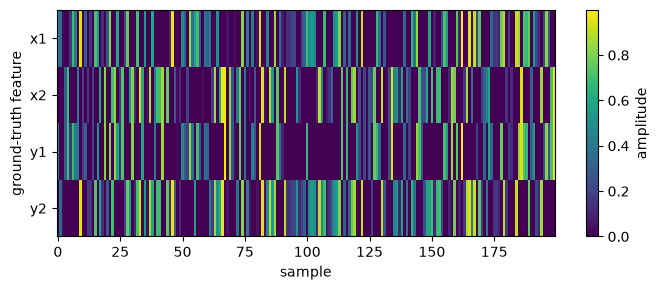

In [9]:
model = make_correlated_amplitude_model(toy_training, device=DEVICE)
feature_batch = model.get_batch(2_000)

assert torch.all((feature_batch[:, :2] > 0).sum(dim=1) == 1)
assert torch.all((feature_batch[:, 2:] > 0).sum(dim=1) == 1)
assert torch.allclose(feature_batch[:, :2].sum(1), feature_batch[:, 2:].sum(1))

print('Probability table:\n', model.get_prob_table())
print('First eight samples:\n', feature_batch[:8].cpu())
print('Maximum sampled amplitude:', feature_batch.max().item())
plot_feature_batch(feature_batch);

## 3. Train the original tied-weight toy model

The model architecture, forward pass, sampler, loss, and AdamW settings come from `superposition-geometry-toys`. The local wrapper removes only the source method's live notebook plotting side effects.

Saved artifacts/toy_model_full.pt


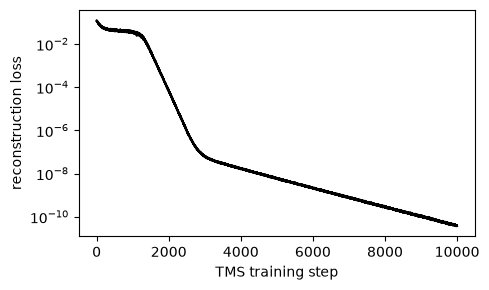

In [10]:
toy_checkpoint = ARTIFACTS / ('toy_model_full.pt' if FULL_RUN else 'toy_model_quick.pt')
if toy_checkpoint.exists():
    load_toy_model(model, toy_checkpoint)
    toy_losses = []
    print('Loaded', toy_checkpoint)
else:
    toy_losses = train_toy_model(model, toy_training)
    save_toy_model(model, toy_checkpoint)
    print('Saved', toy_checkpoint)

if toy_losses:
    plot_training_loss(toy_losses);

## 4. Train SAELens SAE(s)

The source used `n_inst=5`, which stored five independent autoencoders in one custom tensor. Here that maps to five independent SAELens seeds in a full run. SAELens owns the standard ReLU SAE, L1 loss, normalization constraints, optimizer/trainer, and checkpoint format. `apply_b_dec_to_input=False` matches the source experiment's `pre_encoder_bias=False`.

In [11]:
primary_saes = []
for seed in primary_seeds:
    run_cfg = replace(sae_training, seed=seed)
    run_dir = ARTIFACTS / f'primary_sae_{"full" if FULL_RUN else "quick"}_seed{seed}'
    if (run_dir / 'cfg.json').exists():
        sae = load_sae(run_dir, device=DEVICE)
        print('Loaded', run_dir)
    else:
        sae = train_sae(model, run_cfg, device=DEVICE)
        save_sae(sae, run_dir)
        print('Saved', run_dir)
    primary_saes.append(sae)

Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed0


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed1


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed2


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed3


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed4


## 5. Evaluate and visualize

The plots retain the source experiment's comparisons: ground-truth TMS directions, SAE decoder directions, decoder cosine similarity, and SAE responses to individual data features. They are adapted for SAELens's two-dimensional `W_dec` (the old autoencoder used a leading `n_inst` axis).

seed 0: {'mse': 0.02088499814271927, 'normalized_mse': 0.33535781502723694, 'mean_l0': 0.8932999968528748, 'mean_l1': 0.5893797874450684}
seed 1: {'mse': 0.020956695079803467, 'normalized_mse': 0.22852660715579987, 'mean_l0': 0.894599974155426, 'mean_l1': 0.5397453308105469}
seed 2: {'mse': 0.1112840473651886, 'normalized_mse': 15827.0546875, 'mean_l0': 1.3795000314712524, 'mean_l1': 0.5509402751922607}
seed 3: {'mse': 0.11766218394041061, 'normalized_mse': 2412.680908203125, 'mean_l0': 0.8615999817848206, 'mean_l1': 0.5484055876731873}
seed 4: {'mse': 0.11064635962247849, 'normalized_mse': 625.2479248046875, 'mean_l0': 1.1687999963760376, 'mean_l1': 0.5331358313560486}


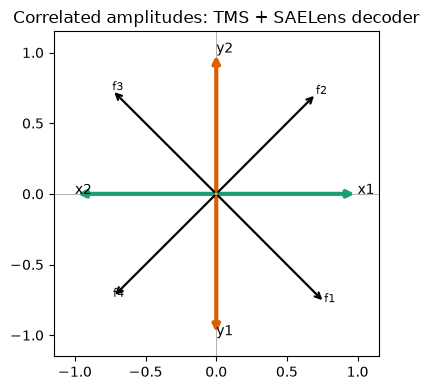

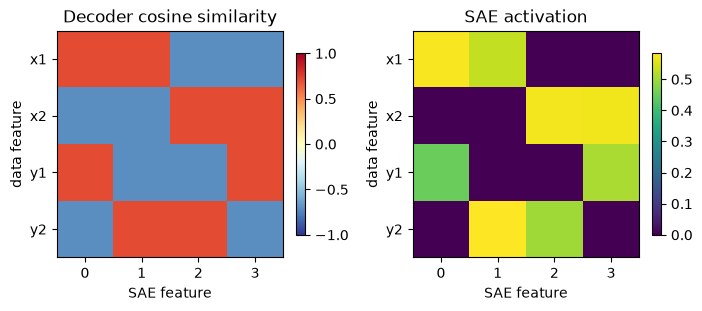

In [12]:
for seed, sae in zip(primary_seeds, primary_saes):
    print(f'seed {seed}:', evaluate_sae(model, sae, samples=10_000))

best_sae = select_best_sae(model, primary_saes, samples=10_000)
plot_geometry(model, best_sae, title='Correlated amplitudes: TMS + SAELens decoder');
plot_sae_matrices(model, best_sae);

## 6. Optional source 5×5 SAE grid

This reproduces only the grid belonging to correlated feature amplitudes. It does not run later notebook sections. With `FULL_RUN=True`, each of 25 settings trains five independent SAELens seeds on 128M samples, matching the source's hyperparameters and instance count.

In [ ]:
if RUN_GRID:
    grid_base = sae_training if FULL_RUN else replace(sae_training, training_samples=50_000)
    grid_seeds = SOURCE_INSTANCE_SEEDS if FULL_RUN else (0,)
    grid_results = train_sae_grid(
        model, grid_base, learning_rates=SOURCE_GRID_LRS,
        l1_coefficients=SOURCE_GRID_L1_COEFFICIENTS, seeds=grid_seeds,
        device=DEVICE,
    )
    plot_sae_grid(
        model, grid_results, SOURCE_GRID_LRS, SOURCE_GRID_L1_COEFFICIENTS
    );
else:
    print('Grid skipped. Set RUN_GRID = True to run it.')

## Implementation boundary

**Reused:** `ToyModelConfig`, `ComposedFeatureTMS`, its pair sampler/probability table, tied-weight forward pass, importance-weighted MSE, and source hyperparameters.

**SAELens:** `StandardTrainingSAE`, `StandardTrainingSAEConfig`, `SAETrainer`, the SAE loss/training mechanics, and native save/load.

**Added only to fill gaps:** a non-interactive wrapper around TMS training, an iterator from `model.h` to SAELens, a five-seed replacement for legacy `n_inst=5`, checkpoint orchestration, evaluation metrics, and SAELens-shaped visualization helpers.